# Assignment No.5
## Name: Negar Fathi
### Student ID: 400222069

#### 1. Data Preview

In [431]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew
from sklearn.preprocessing import PowerTransformer
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_log_error
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
import xgboost as xgb
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_selection import mutual_info_regression
from scipy.stats import chi2_contingency
import itertools
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OrdinalEncoder

In [432]:
df = pd.read_csv('train.csv')

In [433]:
df.shape

(1100000, 21)

In [434]:
df.shape

(1100000, 21)

In [435]:
df.head()

,ID,Years Lived,Sex,Yearly Earnings,Relationship Status,Dependent Count,Academic Standing,Job Title,Wellness Index,Region,...,Prior Claims,Automobile Age,Financial Rating,Coverage Period,Coverage Commencement,Client Review,Tobacco Use,Physical Activity,Asset Category,Policy Cost
0,0,26.0,Man,8071.0,Unmarried,NaN,Secondary,NaN,17.927378,City,...,0.0,4.0,622.0,2.0,2024-06-10 15:21:39.261856,NaN,Smoker,Everyday,Residence,533.0
1,1,42.0,Man,49.0,Unmarried,2.0,Undergraduate,Jobless,49.828507,City,...,1.0,15.0,568.0,6.0,2023-01-06 15:21:39.272456,Moderate,Smoker,Once a Week,Unit,4795.0
2,2,52.0,Man,80793.0,Spouse,2.0,Doctorate,Jobless,27.539608,Exurban,...,2.0,2.0,467.0,7.0,2021-03-18 15:21:39.237118,Satisfactory,Non-Smoker,Seldom,Residence,151.0
3,3,33.0,Man,30663.0,Unmarried,1.0,Undergraduate,Freelancer,24.355045,Countryside,...,1.0,10.0,710.0,2.0,2023-08-28 15:21:39.102694,Unsatisfactory,Non-Smoker,Seldom,Residence,588.0
4,4,34.0,Man,59638.0,Spouse,0.0,Undergraduate,NaN,33.394840,Countryside,...,1.0,10.0,431.0,2.0,2024-03-17 15:21:39.171102,Unsatisfactory,Smoker,Once a Month,Residence,662.0


In [436]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1100000 entries, 0 to 1099999
Data columns (total 21 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   ID                     1100000 non-null  int64  
 1   Years Lived            1082781 non-null  float64
 2   Sex                    1100000 non-null  object 
 3   Yearly Earnings        1058849 non-null  float64
 4   Relationship Status    1083018 non-null  object 
 5   Dependent Count        999297 non-null   float64
 6   Academic Standing      1100000 non-null  object 
 7   Job Title              771458 non-null   object 
 8   Wellness Index         1031954 non-null  float64
 9   Region                 1100000 non-null  object 
 10  Coverage Class         1100000 non-null  object 
 11  Prior Claims           766140 non-null   float64
 12  Automobile Age         1099994 non-null  float64
 13  Financial Rating       973595 non-null   float64
 14  Coverage Period   

In [437]:
df.isnull().sum()

ID                            0
Years Lived               17219
Sex                           0
Yearly Earnings           41151
Relationship Status       16982
Dependent Count          100703
Academic Standing             0
Job Title                328542
Wellness Index            68046
Region                        0
Coverage Class                0
Prior Claims             333860
Automobile Age                6
Financial Rating         126405
Coverage Period               1
Coverage Commencement         0
Client Review             71297
Tobacco Use                   0
Physical Activity             0
Asset Category                0
Policy Cost                   0
dtype: int64

#### 2. EDA

##### 2.1 Visualizing Distribution of Target Variable (Policy Cost)

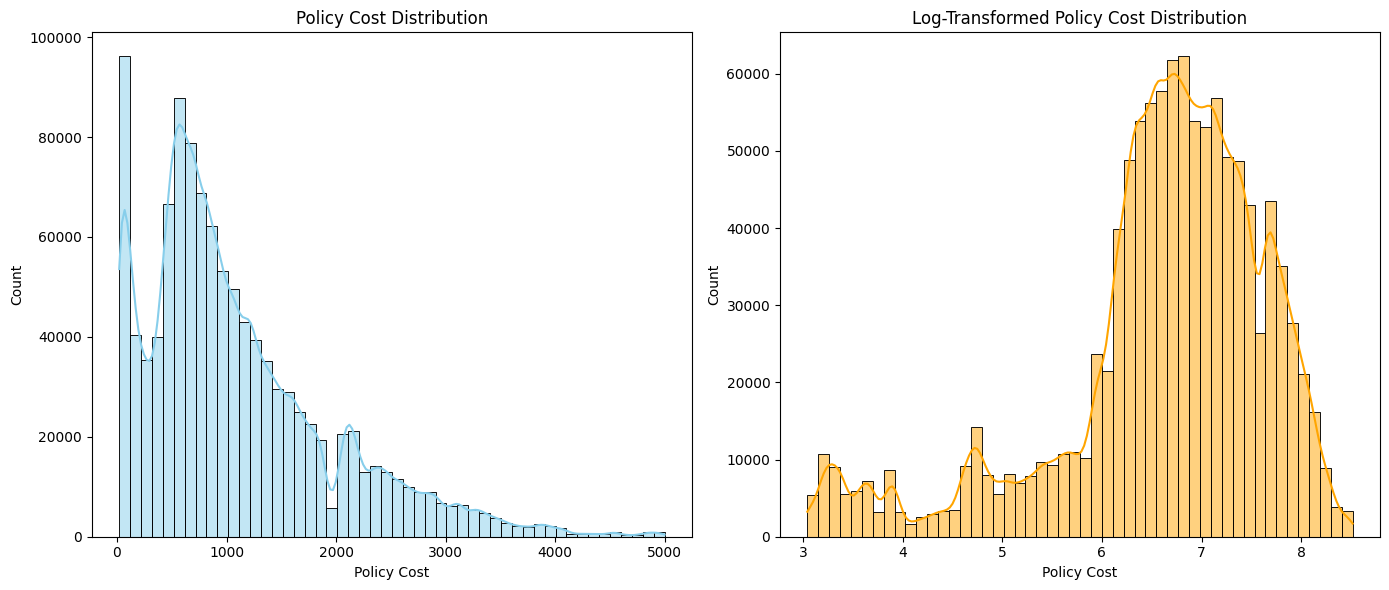

In [ ]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(df['Policy Cost'], bins=50, kde=True, color='skyblue')
plt.title('Policy Cost Distribution')

plt.subplot(1, 2, 2)
sns.histplot(np.log1p(df['Policy Cost']), bins=50, kde=True, color='orange')
plt.title('Log-Transformed Policy Cost Distribution')

plt.tight_layout()
plt.show()

In [ ]:
original_skewness = skew(df['Policy Cost'])
log_skewness = skew(np.log1p(df['Policy Cost']))
print(f"Skewness of original Policy Cost: {original_skewness:.2f}")
print(f"Skewness after log1p transformation: {log_skewness:.2f}")

Skewness of original Policy Cost: 1.24
Skewness after log1p transformation: -1.26


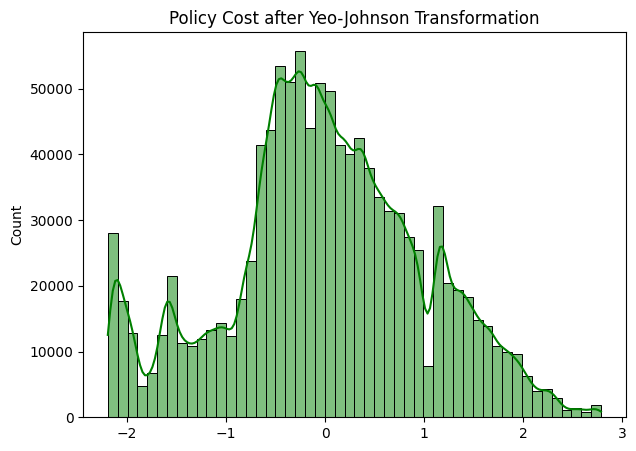

In [ ]:
pt = PowerTransformer(method='yeo-johnson')
policy_cost_yj = pt.fit_transform(df[['Policy Cost']])


plt.figure(figsize=(7, 5))
sns.histplot(policy_cost_yj.flatten(), bins=50, kde=True, color='green')
plt.title('Policy Cost after Yeo-Johnson Transformation')
plt.show()

In [441]:
yj_skewness = skew(policy_cost_yj)
print(f"Skewness after Yeo-Johnson transformation: {yj_skewness}")

Skewness after Yeo-Johnson transformation: [-0.05790705]


##### 2.2 Visualizing Distributions of Key Numeric Features

In [442]:
numeric_features = [
    'Years Lived', 'Yearly Earnings', 'Dependent Count', 'Wellness Index',
    'Prior Claims', 'Automobile Age', 'Financial Rating', 'Coverage Period'
]

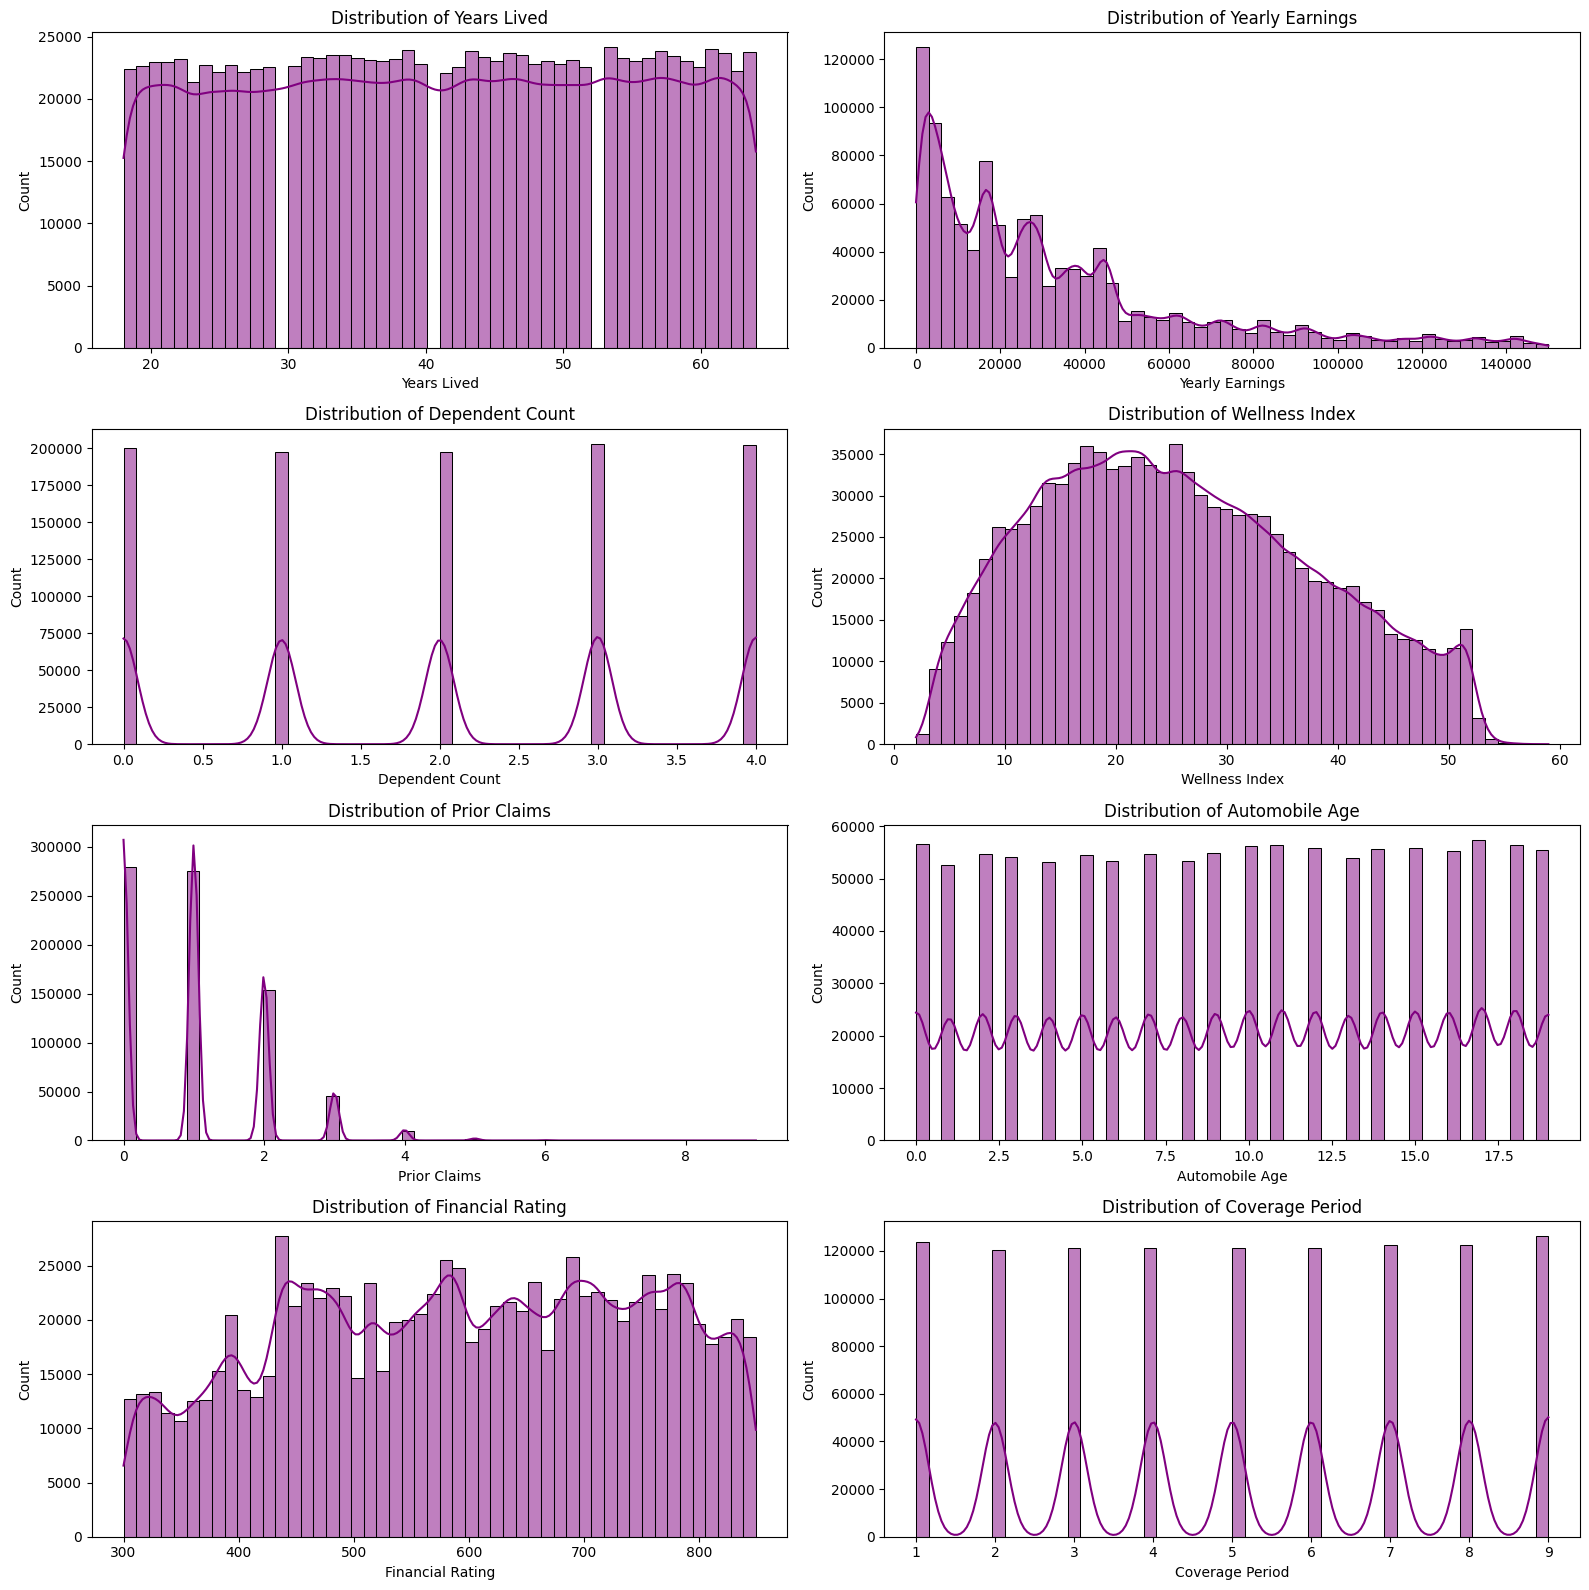

In [443]:
fig, axs = plt.subplots(nrows=4, ncols=2, figsize=(16, 16))
axs = axs.flatten()

for i, feature in enumerate(numeric_features):
    sns.histplot(df[feature], bins=50, kde=True, ax=axs[i], color='purple')
    axs[i].set_title(f'Distribution of {feature}')
    
plt.tight_layout()
plt.show()

##### 2.3 Boxplots for Outlier Detection

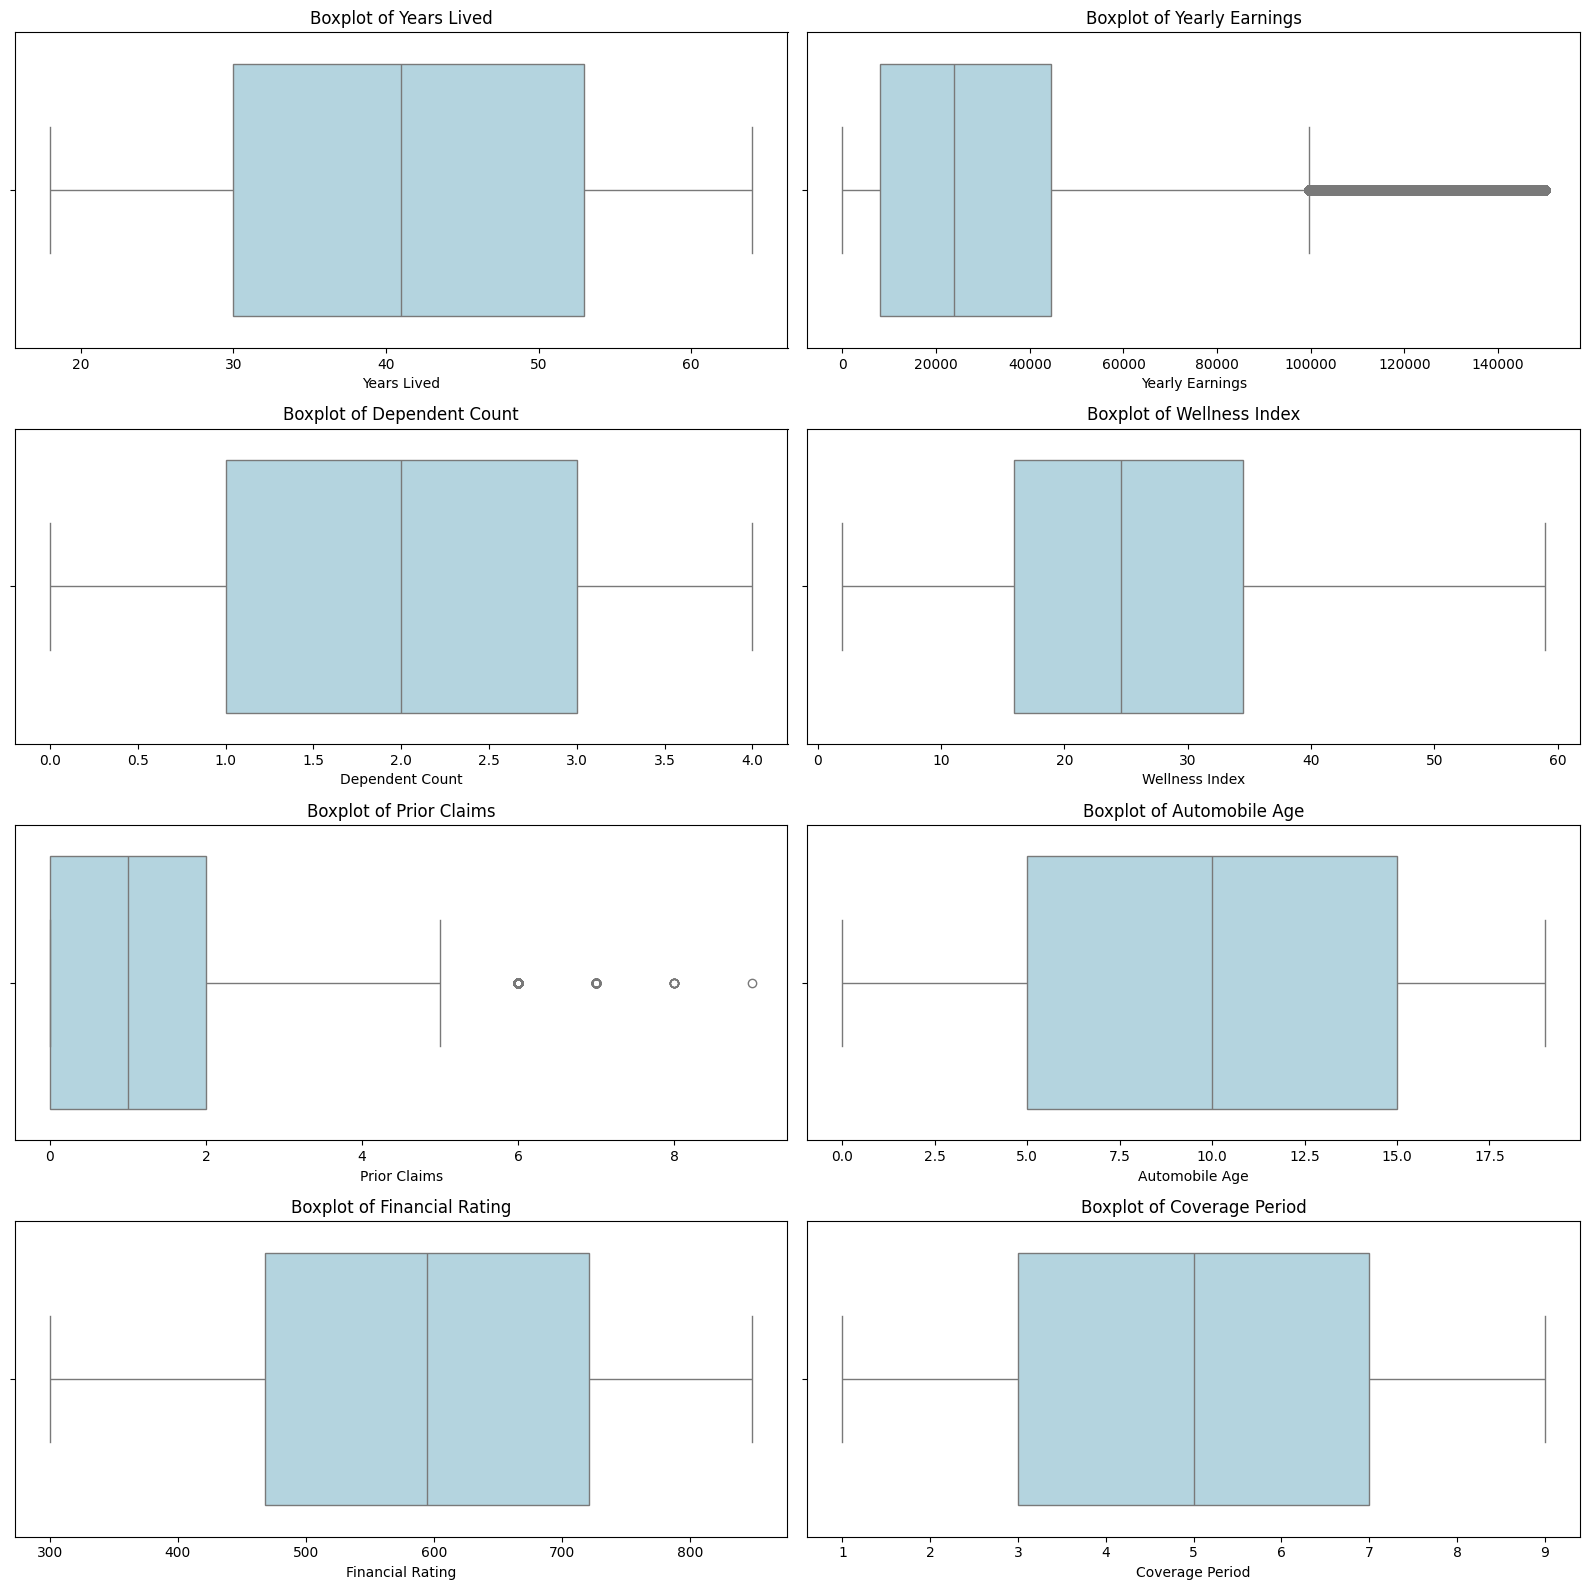

In [444]:
fig, axs = plt.subplots(nrows=4, ncols=2, figsize=(16, 16))
axs = axs.flatten()

for i, feature in enumerate(numeric_features):
    sns.boxplot(x=df[feature], ax=axs[i], color='lightblue')
    axs[i].set_title(f'Boxplot of {feature}')
    
plt.tight_layout()
plt.show()

##### 2.4 Missing Values

In [445]:
missing_percent = df.isnull().mean().sort_values(ascending=False) * 100
print("Missing value percentages:\n")
print(missing_percent)

Missing value percentages:

Prior Claims             30.350909
Job Title                29.867455
Financial Rating         11.491364
Dependent Count           9.154818
Client Review             6.481545
Wellness Index            6.186000
Yearly Earnings           3.741000
Years Lived               1.565364
Relationship Status       1.543818
Automobile Age            0.000545
Coverage Period           0.000091
Sex                       0.000000
ID                        0.000000
Region                    0.000000
Coverage Class            0.000000
Academic Standing         0.000000
Coverage Commencement     0.000000
Tobacco Use               0.000000
Physical Activity         0.000000
Asset Category            0.000000
Policy Cost               0.000000
dtype: float64


In [ ]:
categorical_fill = ['Job Title', 'Client Review', 'Relationship Status']
df[categorical_fill] = df[categorical_fill].fillna('Missing')

In [ ]:
median_fill_cols = [
    'Dependent Count', 'Yearly Earnings', 'Years Lived',
    'Financial Rating', 'Wellness Index'
]
df[median_fill_cols] = df[median_fill_cols].fillna(df[median_fill_cols].median())

In [ ]:
iter_imp = IterativeImputer(random_state=42)
df[['Prior Claims']] = iter_imp.fit_transform(df[['Prior Claims']])


In [ ]:
df.dropna(subset=['Automobile Age', 'Coverage Period'], inplace=True)

In [450]:
print("\nRemaining missing values after imputation:")
print(df.isnull().sum())


Remaining missing values after imputation:
ID                       0
Years Lived              0
Sex                      0
Yearly Earnings          0
Relationship Status      0
Dependent Count          0
Academic Standing        0
Job Title                0
Wellness Index           0
Region                   0
Coverage Class           0
Prior Claims             0
Automobile Age           0
Financial Rating         0
Coverage Period          0
Coverage Commencement    0
Client Review            0
Tobacco Use              0
Physical Activity        0
Asset Category           0
Policy Cost              0
dtype: int64


##### 2.5 Preprocessing

In [451]:
data = df.copy()

In [ ]:
ordinal_features = {
    'Academic Standing': {
        'Secondary': 0,
        'Undergraduate': 1,
        'Graduate': 2,
        'Doctorate': 3
    },
    'Physical Activity': {
        'Seldom': 0,
        'Once a Month': 1,
        'Once a Week': 2,
        'Everyday': 3
    },
    'Client Review': {
        'Unsatisfactory': 0,
        'Satisfactory': 1,
        'Moderate': 2,
        'Missing': 3
    },
    'Coverage Class': {
        'Standard': 0,
        'Full': 1,
        'Superior': 2
    }
}

In [453]:
for col, mapping in ordinal_features.items():
    df[col] = df[col].map(mapping)

In [ ]:
df['Coverage Commencement'] = pd.to_datetime(df['Coverage Commencement'], errors='coerce')

df['Coverage_Year'] = df['Coverage Commencement'].dt.year
df['Coverage_Month'] = df['Coverage Commencement'].dt.month
df['Coverage_Day'] = df['Coverage Commencement'].dt.day
df['Coverage_DayOfWeek'] = df['Coverage Commencement'].dt.dayofweek

df.drop(columns=['Coverage Commencement'], inplace=True)


In [ ]:
nominal_cols = [
    'Sex', 'Relationship Status', 'Job Title',
    'Region', 'Tobacco Use', 'Asset Category'
]

df = pd.get_dummies(df, columns=nominal_cols, drop_first=False)

In [456]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1099993 entries, 0 to 1099999
Data columns (total 36 columns):
 #   Column                         Non-Null Count    Dtype  
---  ------                         --------------    -----  
 0   ID                             1099993 non-null  int64  
 1   Years Lived                    1099993 non-null  float64
 2   Yearly Earnings                1099993 non-null  float64
 3   Dependent Count                1099993 non-null  float64
 4   Academic Standing              1099993 non-null  int64  
 5   Wellness Index                 1099993 non-null  float64
 6   Coverage Class                 1099993 non-null  int64  
 7   Prior Claims                   1099993 non-null  float64
 8   Automobile Age                 1099993 non-null  float64
 9   Financial Rating               1099993 non-null  float64
 10  Coverage Period                1099993 non-null  float64
 11  Client Review                  1099993 non-null  int64  
 12  Physical Activity  

#### 3. Base Learners

In [457]:
df.drop(columns=['ID'], inplace=True)

X = df.drop(columns=['Policy Cost'])
y = df['Policy Cost']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [458]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [459]:
def rmsle(y_true, y_pred):
    return np.sqrt(mean_squared_log_error(y_true, np.maximum(0, y_pred)))  # cap negative preds

In [460]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
lr_preds = lr.predict(X_test_scaled)
print("Linear Regression RMSLE:", rmsle(y_test, lr_preds))

Linear Regression RMSLE: 1.169860329408513


In [461]:
dt = DecisionTreeRegressor(max_depth=10, min_samples_leaf=100)
dt.fit(X_train, y_train)
dt_preds = dt.predict(X_test)
print("Decision Tree RMSLE:", rmsle(y_test, dt_preds))

Decision Tree RMSLE: 1.131967875801811


In [462]:
xgb_reg = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=10,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)
xgb_reg.fit(X_train, y_train)
xgb_preds = xgb_reg.predict(X_test)
print("XGBoost RMSLE:", rmsle(y_test, xgb_preds))

XGBoost RMSLE: 1.1343327686722735


#### 4. Feature Engineering

In [463]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1099993 entries, 0 to 1099999
Data columns (total 21 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   ID                     1099993 non-null  int64  
 1   Years Lived            1099993 non-null  float64
 2   Sex                    1099993 non-null  object 
 3   Yearly Earnings        1099993 non-null  float64
 4   Relationship Status    1099993 non-null  object 
 5   Dependent Count        1099993 non-null  float64
 6   Academic Standing      1099993 non-null  object 
 7   Job Title              1099993 non-null  object 
 8   Wellness Index         1099993 non-null  float64
 9   Region                 1099993 non-null  object 
 10  Coverage Class         1099993 non-null  object 
 11  Prior Claims           1099993 non-null  float64
 12  Automobile Age         1099993 non-null  float64
 13  Financial Rating       1099993 non-null  float64
 14  Coverage Period        

In [464]:
cat_features = [
    'Sex', 'Relationship Status', 'Academic Standing', 'Job Title',
    'Region', 'Coverage Class', 'Client Review', 'Tobacco Use',
    'Physical Activity', 'Asset Category'
]

In [465]:
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k - 1)*(r - 1)) / (n - 1))
    rcorr = r - ((r - 1)**2) / (n - 1)
    kcorr = k - ((k - 1)**2) / (n - 1)
    return np.sqrt(phi2corr / min(kcorr - 1, rcorr - 1))

In [ ]:
cramers_results = pd.DataFrame(index=cat_features, columns=cat_features)
for f1 in cat_features:
    for f2 in cat_features:
        if f1 == f2:
            cramers_results.loc[f1, f2] = 1.0
        else:
            cramers_results.loc[f1, f2] = cramers_v(data[f1], data[f2])

cramers_results = cramers_results.astype(float)

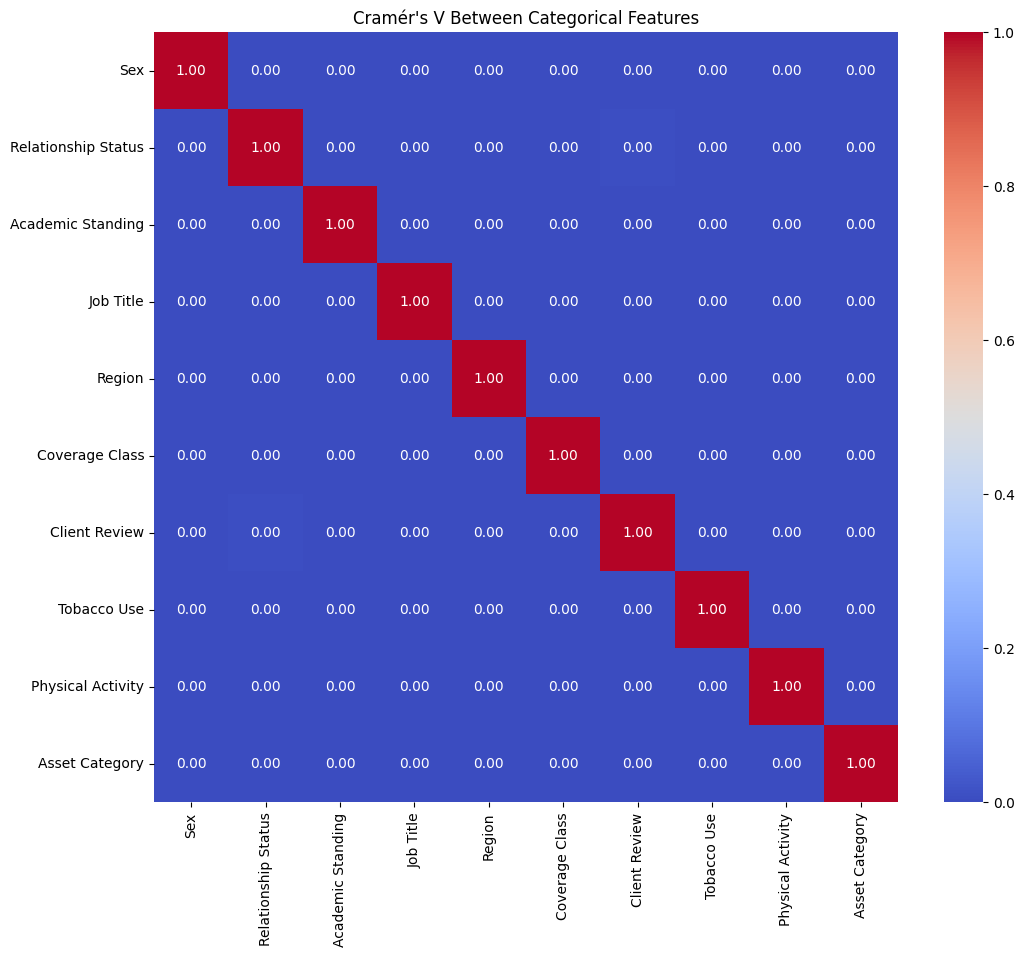

In [ ]:
plt.figure(figsize=(12, 10))
sns.heatmap(cramers_results, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Cramér's V Between Categorical Features")
plt.show()

In [ ]:
data['Sex_RelStatus'] = data['Sex'] + "_" + data['Relationship Status']
data['Region_Academic'] = data['Region'] + "_" + data['Academic Standing']

In [ ]:
for col in ['Sex_RelStatus', 'Region_Academic']:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])

In [ ]:
mi_scores = mutual_info_classif(
    data[['Sex_RelStatus', 'Region_Academic']],
    data['Policy Cost'],
    discrete_features=True,
    random_state=42
)
mi_df = pd.Series(mi_scores, index=['Sex_RelStatus', 'Region_Academic']).sort_values(ascending=False)
print(mi_df)

Region_Academic    0.025693
Sex_RelStatus      0.016500
dtype: float64


In [ ]:
features = ['Region', 'Academic Standing', 'Sex', 'Relationship Status']
df_encoded = data.copy()

for col in features:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])

X = df_encoded[features]
y = df_encoded['Policy Cost']

mi_scores = mutual_info_classif(X, y, discrete_features=True, random_state=42)
mi_series = pd.Series(mi_scores, index=features).sort_values(ascending=False)
print(mi_series)

Relationship Status    0.007749
Academic Standing      0.007538
Region                 0.005017
Sex                    0.002503
dtype: float64


In [ ]:
data['TobaccoUse_PhysicalActivity'] = data['Tobacco Use'] + "_" + data['Physical Activity']
data['Region_CoverageClass'] = data['Region'] + "_" + data['Coverage Class']

for col in ['TobaccoUse_PhysicalActivity', 'Region_CoverageClass']:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])

In [ ]:
mi_scores = mutual_info_classif(
    data[['TobaccoUse_PhysicalActivity', 'Region_CoverageClass']],
    data['Policy Cost'],
    discrete_features=True,
    random_state=42
)
mi_df = pd.Series(mi_scores, index=['TobaccoUse_PhysicalActivity', 'Region_CoverageClass']).sort_values(ascending=False)
print(mi_df)

Region_CoverageClass           0.018936
TobaccoUse_PhysicalActivity    0.016628
dtype: float64


In [ ]:
features = ['Region', 'Coverage Class', 'Tobacco Use', 'Physical Activity']
df_encoded = data.copy()

for col in features:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])

X = df_encoded[features]
y = df_encoded['Policy Cost']

mi_scores = mutual_info_classif(X, y, discrete_features=True, random_state=42)
mi_series = pd.Series(mi_scores, index=features).sort_values(ascending=False)
print(mi_series)

Physical Activity    0.007689
Region               0.005017
Coverage Class       0.004978
Tobacco Use          0.002422
dtype: float64


In [475]:
academic_mapping = {
    'Secondary': 0,
    'Undergraduate': 1,
    'Graduate': 2,
    'Doctorate': 3
}
data['Academic Standing'] = data['Academic Standing'].map(academic_mapping)

activity_mapping = {
    'Seldom': 0,
    'Once a Month': 1,
    'Once a Week': 2,
    'Everyday': 3
}
data['Physical Activity'] = data['Physical Activity'].map(activity_mapping)

review_mapping = {
    'Unsatisfactory': 0,
    'Satisfactory': 1,
    'Moderate': 2,
    'Missing': 3
}
data['Client Review'] = data['Client Review'].map(review_mapping)

coverage_mapping = {
    'Standard': 0,
    'Full': 1,
    'Superior': 2
}
data['Coverage Class'] = data['Coverage Class'].map(coverage_mapping)

In [ ]:
data['Coverage Commencement'] = pd.to_datetime(data['Coverage Commencement'], errors='coerce')
data['Coverage_Year'] = data['Coverage Commencement'].dt.year
data['Coverage_Month'] = data['Coverage Commencement'].dt.month
data['Coverage_Day'] = data['Coverage Commencement'].dt.day
data['Coverage_DayOfWeek'] = data['Coverage Commencement'].dt.dayofweek
data.drop('Coverage Commencement', axis=1, inplace=True)

In [477]:
data['Sex_RelStatus'] = data['Sex'] + "_" + data['Relationship Status']
data['Region_Academic'] = data['Region'] + "_" + data['Academic Standing'].astype(str)
data['TobaccoUse_PhysicalActivity'] = data['Tobacco Use'] + "_" + data['Physical Activity'].astype(str)
data['Region_CoverageClass'] = data['Region'] + "_" + data['Coverage Class'].astype(str)

In [478]:
data.drop(columns=['Sex', 'Relationship Status', 'Region', 'Tobacco Use'], inplace=True)

In [479]:
combo_cols = ['Sex_RelStatus', 'Region_Academic', 'TobaccoUse_PhysicalActivity', 'Region_CoverageClass']
data[combo_cols] = OrdinalEncoder().fit_transform(data[combo_cols])

In [480]:
data = pd.get_dummies(data, columns=['Job Title', 'Asset Category'], drop_first=False, dummy_na=True)

In [481]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1099993 entries, 0 to 1099999
Data columns (total 31 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   ID                           1099993 non-null  int64  
 1   Years Lived                  1099993 non-null  float64
 2   Yearly Earnings              1099993 non-null  float64
 3   Dependent Count              1099993 non-null  float64
 4   Academic Standing            1099993 non-null  int64  
 5   Wellness Index               1099993 non-null  float64
 6   Coverage Class               1099993 non-null  int64  
 7   Prior Claims                 1099993 non-null  float64
 8   Automobile Age               1099993 non-null  float64
 9   Financial Rating             1099993 non-null  float64
 10  Coverage Period              1099993 non-null  float64
 11  Client Review                1099993 non-null  int64  
 12  Physical Activity            1099993 non-null  

In [482]:
data.drop(columns=['ID'], inplace=True)
X = data.drop(columns=["Policy Cost"])
y = data["Policy Cost"]

In [483]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [484]:
scaler_2 = StandardScaler()
X_train_scaled_2 = scaler_2.fit_transform(X_train)
X_test_scaled_2 = scaler_2.transform(X_test)

In [485]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled_2, y_train)
lr_preds = lr_model.predict(X_test_scaled_2)
lr_rmsle = rmsle(y_test, lr_preds)

In [486]:
dt_model = DecisionTreeRegressor(max_depth=10, random_state=42)
dt_model.fit(X_train_scaled_2, y_train)
dt_preds = dt_model.predict(X_test_scaled_2)
dt_rmsle = rmsle(y_test, dt_preds)

In [487]:
xgb_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)
xgb_model.fit(X_train_scaled_2, y_train)
xgb_preds = xgb_model.predict(X_test_scaled_2)
xgb_rmsle = rmsle(y_test, xgb_preds)

In [488]:
print(f"Linear Regression RMSLE: {lr_rmsle}")
print(f"Decision Tree RMSLE: {dt_rmsle}")
print(f"XGBoost RMSLE: {xgb_rmsle}")

Linear Regression RMSLE: 1.1700229462821705
Decision Tree RMSLE: 1.1333310285012983
XGBoost RMSLE: 1.1434086951469578


#### 5. Test

In [489]:
test = pd.read_csv('x_test.csv')

In [490]:
test.shape

(100000, 20)

In [491]:
data_test = test.copy()

In [492]:
data_test.drop(columns=['ID'], inplace=True)

In [ ]:
categorical_cols = ['Job Title', 'Client Review', 'Relationship Status']
data_test[categorical_cols] = data_test[categorical_cols].fillna('Missing')

In [ ]:
median_impute_cols = ['Dependent Count', 'Yearly Earnings', 'Years Lived', 'Financial Rating', 'Wellness Index']
data_test[median_impute_cols] = data_test[median_impute_cols].fillna(df[median_impute_cols].median())  # from training set

In [ ]:
data_test[['Prior Claims']] = iter_imp.transform(data_test[['Prior Claims']])  # fitted on training

In [ ]:
ordinal_mappings = {
    'Academic Standing': {
        'Secondary': 0,
        'Undergraduate': 1,
        'Graduate': 2,
        'Doctorate': 3
    },
    'Physical Activity': {
        'Seldom': 0,
        'Once a Month': 1,
        'Once a Week': 2,
        'Everyday': 3
    },
    'Client Review': {
        'Unsatisfactory': 0,
        'Satisfactory': 1,
        'Moderate': 2,
        'Missing': 3
    }
}
for col, mapping in ordinal_mappings.items():
    data_test[col] = data_test[col].map(mapping)

coverage_class_mapping = {
    'Standard': 0,
    'Full': 1,
    'Superior': 2
}
data_test['Coverage Class'] = data_test['Coverage Class'].map(coverage_class_mapping)

In [ ]:
data_test['Coverage Commencement'] = pd.to_datetime(data_test['Coverage Commencement'], errors='coerce')
data_test['Coverage_Year'] = data_test['Coverage Commencement'].dt.year
data_test['Coverage_Month'] = data_test['Coverage Commencement'].dt.month
data_test['Coverage_Day'] = data_test['Coverage Commencement'].dt.day
data_test['Coverage_DayOfWeek'] = data_test['Coverage Commencement'].dt.dayofweek
data_test.drop('Coverage Commencement', axis=1, inplace=True)


In [ ]:
data_test['Region_Academic'] = data_test['Region'].astype(str) + "_" + data_test['Academic Standing'].astype(str)
data_test['Sex_RelStatus'] = data_test['Sex'].astype(str) + "_" + data_test['Relationship Status'].astype(str)
data_test['Region_CoverageClass'] = data_test['Region'].astype(str) + "_" + data_test['Coverage Class'].astype(str)
data_test['TobaccoUse_PhysicalActivity'] = data_test['Tobacco Use'].astype(str) + "_" + data_test['Physical Activity'].astype(str)

In [ ]:
one_hot_cols = ['Sex', 'Relationship Status', 'Job Title', 'Region',
                'Tobacco Use', 'Asset Category',
                'Region_Academic', 'Sex_RelStatus',
                'Region_CoverageClass', 'TobaccoUse_PhysicalActivity']
data_test = pd.get_dummies(data_test, columns=one_hot_cols, drop_first=False)

In [ ]:
X = df.drop(columns=["Policy Cost"])
y = df["Policy Cost"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

data_test = data_test.reindex(columns=X_train.columns, fill_value=0)

In [501]:
data_test_scaled = scaler.transform(data_test)

In [502]:
test_predictions = dt.predict(data_test_scaled)

c:\Users\negar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


In [503]:
submission = pd.DataFrame({
    'ID': test['ID'],
    'Policy Cost': test_predictions
})
submission.to_csv('submission.csv', index=False)

PermissionError: [Errno 13] Permission denied: 'submission.csv'